# Bootstrap del proceso completo

El error estándar que devuelve la regresión trata los pares emparejados como un
hecho fijo. No lo son: los construimos con los mismos datos. En otra realización
el propensity score saldría distinto y el emparejamiento elegiría otros
controles. Ese brinco no está en ninguna fórmula analítica.

El bootstrap lo mide por fuerza bruta: remuestrea la muestra que tenemos,
**rehace todo el proceso en cada repetición** —logística, emparejamiento y
estimación— y observa cuánto se mueve el coeficiente. Es lo que pidió Alberto en
el punto 3a, *"empezando con el cálculo del propensity score"*.

Se corre sobre las **veinte combinaciones** de la tesis —cinco radios por cuatro
niveles de severidad— con **2,000 repeticiones** cada una.

## Lo que se remuestrea, y lo que no

**Se remuestrean** las 99 unidades tratadas y el pool completo de controles, con
reemplazo. Sobre esa muestra se reajusta la logística y se rehace el
emparejamiento con las mismas reglas: caliper, desempate por Mahalanobis y
separación entre controles.

Se remuestrean las **99**, no las 93, porque en el pipeline compiten todas por
los controles y el recorte a la muestra común ocurre después. Si solo compitieran
93, encontrarían mejores controles de los que les tocan en realidad.

**Se remuestrean componentes, no unidades sueltas.** Dos círculos tratados que
comparten área registran los mismos incidentes, así que no son observaciones
independientes: por eso el error estándar analítico agrupa por componente
traslapada. Un bootstrap que sorteara unidades por separado rompería esa
dependencia y subestimaría la varianza. El sorteo es entonces de componentes: si
las unidades 32 y 77 comparten área, entran o salen juntas. Cada control es su
propia componente, porque no comparte incidentes con nadie.

A 100 m no hay traslape —las 99 tratadas son 99 componentes de una unidad— así
que ahí los dos bootstraps son el mismo objeto. A 300 m son 77 componentes, con
36 unidades repartidas en grupos de 2 a 5.

Para poder medir cuánto pesa esa diferencia, el bootstrap por unidades se corre
también en los radios de 100 y 300 y se comparan los dos.

**No se remuestrea** la intersección de los cinco radios. Las 93 se mantienen
fijas porque son la definición del estimando, y recalcularla exigiría cinco
emparejamientos por repetición. Hay que declararlo: el intervalo **no** incorpora
la incertidumbre de qué unidades sobreviven en los cinco radios a la vez.

## Por qué se puede correr

Tres cosas lo hacen viable en menos de una hora:

1. **Los cruces espaciales no cambian entre repeticiones.** Las covariables de
   cada unidad y su serie mensual de incidentes ya están calculadas; lo que se
   rehace es la logística y el emparejamiento, 330 ms por repetición.
2. **El emparejamiento no depende del nivel de severidad.** Un solo remuestreo
   por radio sirve para las cuatro variables de resultado, lo que ahorra un
   factor de cuatro.
3. **La regresión usa la transformación intragrupo de dos vías** en vez de armar
   266 dummies: 1.7 ms en vez de un par de segundos. Sobre un panel balanceado da
   exactamente el mismo coeficiente, y la celda de verificación lo comprueba.

Las especificaciones (1) y (2) dan el mismo coeficiente por construcción —el
regresor residualizado es ortogonal a los efectos fijos en un panel balanceado
con tratamiento simultáneo—, así que por repetición se calculan dos coeficientes
y no tres.

## Una advertencia teórica

Abadie e Imbens (2008) demostraron que el bootstrap no es formalmente válido para
estimadores de vecino más cercano con número fijo de vecinos: el emparejamiento
no es una función suficientemente suave de la distribución de los datos. Es parte
de por qué Alberto ofrece Sant'Anna y Zhao como alternativa. Esto es la mejor
aproximación disponible sin cambiar de estimador, no una prueba.


In [1]:
from nbsetup import *
from pipeline import Datos, muestra_comun, Panel, NIVELES_TESIS
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.linear_model import LogisticRegression
import time

REPETICIONES = 2_000
SEMILLA = 0

datos = Datos()
emparejamientos, comunes = muestra_comun(datos)
print(f"{len(comunes)} tratadas comunes a los cinco radios")


93 tratadas comunes a los cinco radios


In [2]:
# precómputo por radio: todo lo que NO cambia entre repeticiones
def preparar(emparejamiento):
    """Covariables, coordenadas y la serie mensual de cada unidad, por nivel."""
    panel = Panel(emparejamiento)
    ps = emparejamiento.datos_ps
    uids = ps.index.to_numpy()
    malla = pd.MultiIndex.from_product([uids, panel.periodos.t], names=["uid", "t"])

    series = {}
    for etiqueta, niveles in NIVELES_TESIS.items():
        inc = emparejamiento.features.incidentes_asignados
        if niveles is not None:
            inc = inc[inc.incident_level.isin(niveles)]
        i = np.searchsorted(panel.cortes, inc.timestamp, side="right") - 1
        ok = (i >= 0) & (i < len(panel.periodos))
        inc = inc[ok].assign(t=panel.periodos.t.values[i[ok]])
        series[etiqueta] = (inc.groupby(["uid", "t"]).peso.sum()
                            .reindex(malla, fill_value=0.0)
                            .unstack("t").loc[uids].to_numpy())

    # componentes traslapadas entre las tratadas: el bloque que se remuestrea
    posiciones = np.where((ps.tratado == 1).to_numpy())[0]
    ids = [int(u[1:]) for u in uids[posiciones]]
    ov = emparejamiento.features.tratadas.pares_traslapados
    ov = ov[ov.unidad_a.isin(ids) & ov.unidad_b.isin(ids)]
    pos = {u: i for i, u in enumerate(ids)}
    ady = coo_matrix((np.ones(len(ov)),
                      ([pos[a] for a in ov.unidad_a], [pos[b] for b in ov.unidad_b])),
                     shape=(len(ids),) * 2)
    n_comp, etiqueta = connected_components(ady, directed=False)
    grupos = [posiciones[etiqueta == g] for g in range(n_comp)]

    cov = emparejamiento.features.matriz.loc[uids, panel.covariables]
    return {
        "grupos": grupos,
        "uids": uids,
        "tratado": (ps.tratado == 1).to_numpy(),
        "z": emparejamiento.Z.loc[uids].to_numpy(),
        "xy": ps[["x", "y"]].to_numpy(),
        "zcov": ((cov - cov.mean()) / cov.std()).to_numpy(),
        "series": series,
        "post": panel.periodos.post.to_numpy().astype(float),
        "caliper_sd": emparejamiento.caliper_sd,
        "separacion": 2 * emparejamiento.radio_m,
        "comunes": np.array([u in comunes for u in uids]),
        "panel": panel,
    }


In [3]:
# emparejamiento y estimación, reimplementados para correr dentro del bucle
def emparejar(z, tratado, xy, caliper_sd, separacion):
    """Vecino más cercano 1:1 sin reemplazo, igual que `Emparejamiento`."""
    modelo = LogisticRegression(max_iter=5000, C=np.inf,
                                solver="newton-cholesky").fit(z, tratado)
    ps = modelo.predict_proba(z)[:, 1]
    logit = np.log(ps / (1 - ps))
    caliper = caliper_sd * logit.std(ddof=1)
    inv_cov = np.linalg.pinv(np.cov(z.T))

    idx_t = np.where(tratado)[0]
    idx_t = idx_t[np.argsort(-ps[idx_t])]        # las más difíciles eligen primero
    idx_c = np.where(~tratado)[0]
    c_logit, c_xy, c_z = logit[idx_c], xy[idx_c], z[idx_c]

    disponible = np.ones(len(idx_c), dtype=bool)
    ocupados, pares = [], []
    for i in idx_t:
        d_ps = np.abs(c_logit - logit[i])
        elegibles = disponible & (d_ps <= caliper)
        if ocupados:
            elegibles &= cKDTree(np.array(ocupados)).query(c_xy)[0] >= separacion
        if not elegibles.any():
            continue
        cand = np.where(elegibles)[0]
        dif = c_z[cand] - z[i]
        maha = np.einsum("ij,jk,ik->i", dif, inv_cov, dif)
        elegido = cand[np.argmin(maha)]
        pares.append((i, idx_c[elegido]))
        ocupados.append(c_xy[elegido])
        disponible[elegido] = False
    return np.array(pares, dtype=int).reshape(-1, 2)


def dentro(a):
    """Transformación intragrupo de dos vías."""
    return a - a.mean(1, keepdims=True) - a.mean(0, keepdims=True) + a.mean()


def coeficiente(pares, serie, post, zcov=None):
    """Coeficiente del DiD. Con `zcov` es la especificación (3); sin ella, la (2)."""
    filas = np.concatenate([pares[:, 0], pares[:, 1]])
    tratado = np.concatenate([np.ones(len(pares)), np.zeros(len(pares))])

    X = [tratado[:, None] * post[None, :]]
    if zcov is not None:
        X += [zcov[filas, k][:, None] * post[None, :] for k in range(zcov.shape[1])]

    Xd = np.column_stack([dentro(a).ravel() for a in X])
    return np.linalg.lstsq(Xd, dentro(serie[filas]).ravel(), rcond=None)[0][0]


In [4]:
# VERIFICACIÓN: la reimplementación tiene que reproducir el pipeline exactamente
for radio in (100, 300):
    d = preparar(emparejamientos[radio])
    pares = emparejar(d["z"], d["tratado"], d["xy"], d["caliper_sd"], d["separacion"])
    pares = pares[d["comunes"][pares[:, 0]]]

    del_pipeline = emparejamientos[radio].pares
    mismos = set(map(tuple, d["uids"][pares])) == set(
        zip(del_pipeline.tratada, del_pipeline.control))

    for nivel in ("general", "PIC"):
        p = Panel(emparejamientos[radio], niveles=NIVELES_TESIS[nivel])
        for etiqueta, spec, zc in [("(2)", "(2) + EF unidad y tiempo", None),
                                   ("(3)", "(3) + covariables x post", d["zcov"])]:
            obtenido = coeficiente(pares, d["series"][nivel], d["post"], zc)
            esperado = p.estimar(p.especificaciones[spec])["coef"]
            assert abs(obtenido - esperado) < 1e-8, (radio, nivel, etiqueta)
    print(f"radio {radio}: mismos pares {mismos} | los 4 coeficientes coinciden")

print("\nla reimplementación reproduce el pipeline")


radio 100: mismos pares True | los 4 coeficientes coinciden


radio 300: mismos pares True | los 4 coeficientes coinciden

la reimplementación reproduce el pipeline


In [5]:
# el bootstrap: se sortean componentes traslapadas, no unidades sueltas
def bootstrap_radio(d, repeticiones=REPETICIONES, semilla=SEMILLA, por_clusters=True):
    """Remuestrea, rehace logística y emparejamiento, y reestima.

    Con `por_clusters`, las tratadas que comparten área entran o salen juntas.
    Sin él, se sortean unidades sueltas, que es lo que rompe la dependencia.
    """
    rng = np.random.default_rng(semilla)
    idx_t = np.where(d["tratado"])[0]
    idx_c = np.where(~d["tratado"])[0]
    grupos = d["grupos"]

    salida = {(n, e): [] for n in NIVELES_TESIS for e in ("(2)", "(3)")}
    n_pares, n_tratadas = [], []

    for _ in range(repeticiones):
        if por_clusters:
            sorteo = rng.integers(0, len(grupos), len(grupos))
            sel_t = np.concatenate([grupos[g] for g in sorteo])
        else:
            sel_t = rng.choice(idx_t, len(idx_t), replace=True)
        sel = np.concatenate([sel_t, rng.choice(idx_c, len(idx_c), replace=True)])

        pares = emparejar(d["z"][sel], d["tratado"][sel], d["xy"][sel],
                          d["caliper_sd"], d["separacion"])
        if not len(pares):
            continue
        pares = pares[d["comunes"][sel[pares[:, 0]]]]
        if len(pares) < 10:
            continue

        filas = sel[pares]
        n_pares.append(len(pares))
        n_tratadas.append(len(sel_t))
        for nivel, serie in d["series"].items():
            salida[(nivel, "(2)")].append(coeficiente(filas, serie, d["post"]))
            salida[(nivel, "(3)")].append(coeficiente(filas, serie, d["post"], d["zcov"]))

    return ({k: np.array(v) for k, v in salida.items()},
            np.array(n_pares), np.array(n_tratadas))


In [6]:
# correr: por clusters en los cinco radios, por unidades en 100 y 300 para comparar
def correr(por_clusters, radios):
    crudo, filas = {}, []
    for radio in radios:
        e = emparejamientos[radio]
        d = preparar(e)
        t0 = time.time()
        coefs, n_pares, n_trat = bootstrap_radio(d, por_clusters=por_clusters)
        for (nivel, spec), c in coefs.items():
            p = Panel(e, niveles=NIVELES_TESIS[nivel])
            nombre = ("(2) + EF unidad y tiempo" if spec == "(2)"
                      else "(3) + covariables x post")
            o = p.estimar(p.especificaciones[nombre])
            crudo[(radio, nivel, spec)] = c
            filas.append({
                "radio": radio, "nivel": nivel, "especificacion": spec,
                "coef": o["coef"], "EE_analitico": o["EE"],
                "sig_analitico": o["sig"], "media_control": o["media_control"],
                "EE_bootstrap": c.std(ddof=1),
                "ic_bajo": np.percentile(c, 2.5), "ic_alto": np.percentile(c, 97.5),
                "media_bootstrap": c.mean(), "sesgo": c.mean() - o["coef"],
                "percentil_original": 100 * (c < o["coef"]).mean(),
                "repeticiones": len(c),
            })
        print(f"radio {radio}: {len(n_pares)} repeticiones, mediana de "
              f"{int(np.median(n_pares))} pares y {int(np.median(n_trat))} tratadas "
              f"sorteadas, {(time.time() - t0)/60:.1f} min")

    tabla = pd.DataFrame(filas)
    tabla["razon_EE"] = tabla.EE_bootstrap / tabla.EE_analitico
    tabla["cruza_cero"] = (tabla.ic_bajo < 0) & (tabla.ic_alto > 0)
    tabla["ic_bajo_pct"] = 100 * tabla.ic_bajo / tabla.media_control
    tabla["ic_alto_pct"] = 100 * tabla.ic_alto / tabla.media_control
    return crudo, tabla


print("POR CLUSTERS — los cinco radios")
crudo, bootstrap = correr(True, list(emparejamientos))
print()
print("POR UNIDADES — solo 100 y 300, para comparar")
crudo_unidades, bootstrap_unidades = correr(False, [100, 300])


POR CLUSTERS — los cinco radios


radio 100: 2000 repeticiones, mediana de 92 pares y 99 tratadas sorteadas, 10.6 min


radio 150: 2000 repeticiones, mediana de 93 pares y 99 tratadas sorteadas, 11.0 min


radio 200: 2000 repeticiones, mediana de 93 pares y 99 tratadas sorteadas, 11.1 min


radio 250: 2000 repeticiones, mediana de 93 pares y 99 tratadas sorteadas, 11.0 min


radio 300: 2000 repeticiones, mediana de 92 pares y 99 tratadas sorteadas, 11.0 min

POR UNIDADES — solo 100 y 300, para comparar


radio 100: 2000 repeticiones, mediana de 92 pares y 99 tratadas sorteadas, 10.7 min


radio 300: 2000 repeticiones, mediana de 93 pares y 99 tratadas sorteadas, 10.9 min


In [7]:
# el resultado: intervalos de confianza como % de la media del grupo de control
principal = bootstrap.query("especificacion == '(3)'")

print("INTERVALO DE CONFIANZA AL 95%, % DE LA MEDIA DEL CONTROL")
ic = principal.assign(
    ic=lambda d: d.apply(lambda r: f"[{r.ic_bajo_pct:+6.1f}, {r.ic_alto_pct:+6.1f}]", axis=1))
print(ic.pivot(index="nivel", columns="radio", values="ic")
      .reindex(list(NIVELES_TESIS)).to_string())
print()
print("¿ALGUNO NO CRUZA CERO?")
sobreviven = bootstrap[~bootstrap.cruza_cero]
if len(sobreviven):
    print(sobreviven[["radio", "nivel", "especificacion", "coef",
                      "ic_bajo", "ic_alto"]].round(4).to_string(index=False))
else:
    print("ninguno: los", len(bootstrap), "intervalos cruzan cero")
print()
print("RAZÓN ENTRE EL EE DEL BOOTSTRAP Y EL ANALÍTICO")
print(principal.pivot(index="nivel", columns="radio", values="razon_EE")
      .reindex(list(NIVELES_TESIS)).round(2).to_string())


INTERVALO DE CONFIANZA AL 95%, % DE LA MEDIA DEL CONTROL
radio                 100               150               200               250               300
nivel                                                                                            
general  [  -5.7,   +8.0]  [  -6.7,   +4.8]  [  -6.0,   +4.5]  [  -5.6,   +3.1]  [  -6.0,   +2.2]
MIN      [  -8.8,   +6.8]  [  -9.8,   +3.6]  [  -6.8,   +3.7]  [  -5.3,   +3.7]  [  -5.9,   +3.0]
PIC      [  -4.5,  +13.4]  [  -5.7,   +9.6]  [  -7.6,   +8.6]  [  -8.6,   +4.6]  [  -9.2,   +3.4]
FCS      [ -42.1,  +51.3]  [ -33.3,  +51.0]  [ -42.3,  +55.9]  [ -19.4,  +36.7]  [ -17.4,  +37.1]

¿ALGUNO NO CRUZA CERO?
ninguno: los 40 intervalos cruzan cero

RAZÓN ENTRE EL EE DEL BOOTSTRAP Y EL ANALÍTICO
radio     100   150   200   250   300
nivel                                
general  0.80  0.82  0.77  0.71  0.72
MIN      0.71  0.72  0.60  0.59  0.58
PIC      0.99  0.86  0.92  0.87  0.93
FCS      0.78  0.82  0.93  0.78  0.86


In [8]:
# las que el error estándar analítico declaraba significativas
antes = bootstrap[bootstrap.sig_analitico != ""]
print(f"significativas con el EE analítico: {len(antes)}")
if len(antes):
    print(antes[["radio", "nivel", "especificacion", "coef", "EE_analitico",
                 "sig_analitico", "EE_bootstrap", "ic_bajo", "ic_alto",
                 "media_bootstrap", "percentil_original"]].round(4).to_string(index=False))


significativas con el EE analítico: 2
 radio nivel especificacion   coef  EE_analitico sig_analitico  EE_bootstrap  ic_bajo  ic_alto  media_bootstrap  percentil_original
   100   PIC            (2) 0.0759        0.0456             *        0.0421  -0.0435   0.1200           0.0382               80.65
   100   PIC            (3) 0.0848        0.0416            **        0.0413  -0.0398   0.1194           0.0383               86.55


In [9]:
# cuánto cambia remuestrear componentes en vez de unidades
llaves = ["radio", "nivel", "especificacion"]
comp = (bootstrap.set_index(llaves)[["EE_bootstrap", "razon_EE"]]
        .join(bootstrap_unidades.set_index(llaves)[["EE_bootstrap", "razon_EE"]],
              how="inner", lsuffix="_clusters", rsuffix="_unidades"))
comp["cociente"] = comp.EE_bootstrap_clusters / comp.EE_bootstrap_unidades

print("EE DEL BOOTSTRAP: POR CLUSTERS CONTRA POR UNIDADES")
print(comp.query("especificacion == '(3)'").round(4).to_string())
print()
print(f"el EE por clusters es en promedio {comp.cociente.mean():.2f}x el de unidades")
print("a 100 m tiene que ser 1.00: no hay traslape, así que los dos sorteos coinciden")


EE DEL BOOTSTRAP: POR CLUSTERS CONTRA POR UNIDADES
                              EE_bootstrap_clusters  razon_EE_clusters  EE_bootstrap_unidades  razon_EE_unidades  cociente
radio nivel   especificacion                                                                                              
100   general (3)                            0.0778             0.8021                 0.0778             0.8021    1.0000
      MIN     (3)                            0.0530             0.7103                 0.0530             0.7103    1.0000
      PIC     (3)                            0.0413             0.9910                 0.0413             0.9910    1.0000
      FCS     (3)                            0.0034             0.7811                 0.0034             0.7811    1.0000
300   general (3)                            0.1294             0.7157                 0.1199             0.6632    1.0791
      MIN     (3)                            0.0817             0.5848                 0

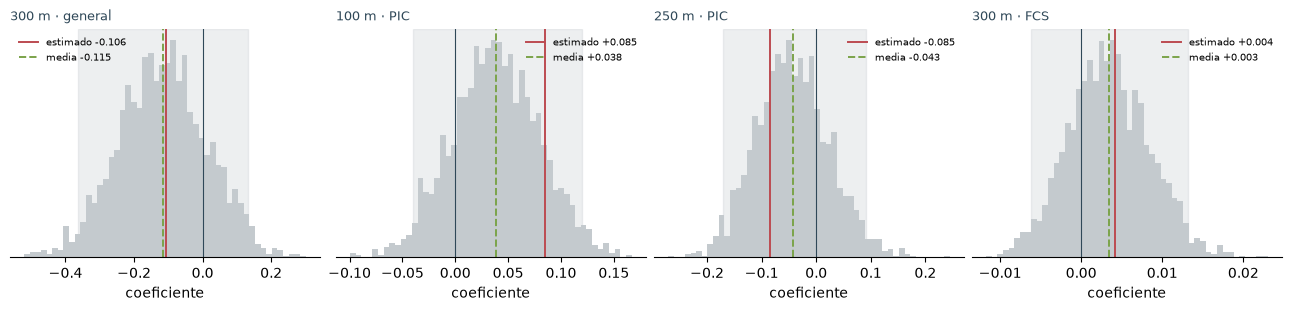

In [10]:
# la distribución bootstrap de las combinaciones que importan
TRATADA, CONTROL, TINTA, GRIS = "#BC4B51", "#7BA34A", "#2F4858", "#C4CACE"
MOSTRAR = [(300, "general", "(3)"), (100, "PIC", "(3)"),
           (250, "PIC", "(3)"), (300, "FCS", "(3)")]

fig, axes = plt.subplots(1, len(MOSTRAR), figsize=(3.2 * len(MOSTRAR), 3),
                         layout="constrained")
for ax, llave in zip(axes, MOSTRAR):
    radio, nivel, spec = llave
    c = crudo[llave]
    fila = bootstrap.query("radio == @radio and nivel == @nivel and especificacion == @spec").iloc[0]
    ax.hist(c, bins=50, color=GRIS, edgecolor="none")
    ax.axvspan(fila.ic_bajo, fila.ic_alto, color=GRIS, alpha=.3, zorder=0)
    ax.axvline(0, color=TINTA, lw=.8)
    ax.axvline(fila.coef, color=TRATADA, lw=1.4, label=f"estimado {fila.coef:+.3f}")
    ax.axvline(c.mean(), color=CONTROL, lw=1.4, ls="--", label=f"media {c.mean():+.3f}")
    ax.set_title(f"{radio} m · {nivel}", fontsize=9, loc="left", color=TINTA)
    ax.set_xlabel("coeficiente")
    ax.legend(frameon=False, fontsize=7)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.set_yticks([])
plt.show()
